# 06 — Churn Tree Models

This notebook tests whether nonlinear tree models add enough value to replace the interpretable logistic-regression benchmark. Random Forest and histogram gradient boosting are evaluated with the **same features, chronological folds, 90-day purge gap, and untouched September holdout** used previously.

The purpose is comparison, not automatic replacement: extra complexity is justified only by a meaningful and stable business improvement.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.inspection import permutation_importance
from sklearn.metrics import brier_score_loss

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from customer_intelligence.churn import (
    baseline_metrics, build_logistic_pipeline, build_tree_pipeline,
    final_temporal_holdout, make_logistic_feature_contract,
    purged_rolling_splits, rolling_logistic_validation,
    rolling_tree_validation, tune_probability_threshold,
    tune_tree_probability_threshold,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

## 1. Reuse the frozen modelling data and validation design

A fair challenger comparison changes the algorithm—not the dataset or evaluation rules. Each row is one eligible customer at one monthly snapshot, and all predictors were frozen at that date.

In [2]:
churn_data = pd.read_csv(
    PROJECT_ROOT / 'data' / 'processed' / 'churn_training_table.csv',
    parse_dates=['SnapshotDate'],
)
feature_contract = make_logistic_feature_contract(churn_data)
validation_dates = pd.to_datetime([
    '2011-02-01', '2011-03-01', '2011-04-01', '2011-05-01'
])
folds = purged_rolling_splits(
    churn_data, validation_dates, horizon_days=90
)
print(f'{len(churn_data):,} customer-snapshot rows')
print(f'{len(feature_contract.all_features)} permitted raw predictors')
print(f'{len(folds)} chronological validation folds')

47,821 customer-snapshot rows
41 permitted raw predictors
4 chronological validation folds


## 2. Define a small, defensible candidate set

Random Forest averages many independent trees. Gradient boosting builds trees sequentially so each new tree focuses on earlier mistakes. For each family, one candidate allows more detail and another is more strongly regularized. The search is intentionally bounded to reduce overfitting, runtime, and accidental selection of a model that merely got lucky on four months.

Trees do not need feature scaling. Missing-value imputation and month encoding still occur inside every training fold to prevent leakage.

In [3]:
tree_candidates = {
    'RF - flexible': (
        'Random Forest',
        {'n_estimators': 150, 'min_samples_leaf': 5, 'max_features': 'sqrt'},
    ),
    'RF - regularized': (
        'Random Forest',
        {'n_estimators': 150, 'min_samples_leaf': 15, 'max_features': 'sqrt'},
    ),
    'HGB - regularized': (
        'Histogram Gradient Boosting',
        {'max_iter': 120, 'learning_rate': 0.07, 'max_leaf_nodes': 31,
         'min_samples_leaf': 50, 'l2_regularization': 2.0},
    ),
    'HGB - shallow': (
        'Histogram Gradient Boosting',
        {'max_iter': 120, 'learning_rate': 0.07, 'max_leaf_nodes': 15,
         'min_samples_leaf': 50, 'l2_regularization': 5.0},
    ),
}
pd.DataFrame([
    {'Candidate': name, 'Model family': family, **settings}
    for name, (family, settings) in tree_candidates.items()
]).set_index('Candidate')

,Model family,n_estimators,min_samples_leaf,max_features,max_iter,learning_rate,max_leaf_nodes,l2_regularization
Candidate,,,,,,,,
RF - flexible,Random Forest,150.0,5,sqrt,NaN,NaN,NaN,NaN
RF - regularized,Random Forest,150.0,15,sqrt,NaN,NaN,NaN,NaN
HGB - regularized,Histogram Gradient Boosting,NaN,50,NaN,120.0,0.07,31.0,2.0
HGB - shallow,Histogram Gradient Boosting,NaN,50,NaN,120.0,0.07,15.0,5.0


## 3. Compare trees across historical months

PR-AUC remains the primary selection metric because churn is the class of interest. Standard deviation shows month-to-month stability; lift measures usefulness when campaign capacity is limited; Brier score checks probability quality.

In [4]:
selected_tree, tree_summary, tree_validation_predictions = rolling_tree_validation(
    churn_data, folds, tree_candidates, contract=feature_contract
)
display(tree_summary.round(4))
print(f'Selected tree candidate: {selected_tree}')

,Candidate,MeanPRAUC,StdPRAUC,MeanROCAUC,MeanLiftAt20Pct,MeanBrierScore,MeanLogLoss,MeanBalancedAccuracy,MeanF1
0,HGB - shallow,0.7770,0.0246,0.7666,1.4544,0.2231,0.6382,0.6686,0.6225
1,HGB - regularized,0.7715,0.0249,0.7602,1.4406,0.2265,0.6489,0.6630,0.6168
2,RF - regularized,0.7694,0.0265,0.7622,1.4434,0.2127,0.6115,0.6757,0.6522
3,RF - flexible,0.7610,0.0274,0.7527,1.4183,0.2168,0.6213,0.6677,0.6407


Selected tree candidate: HGB - shallow


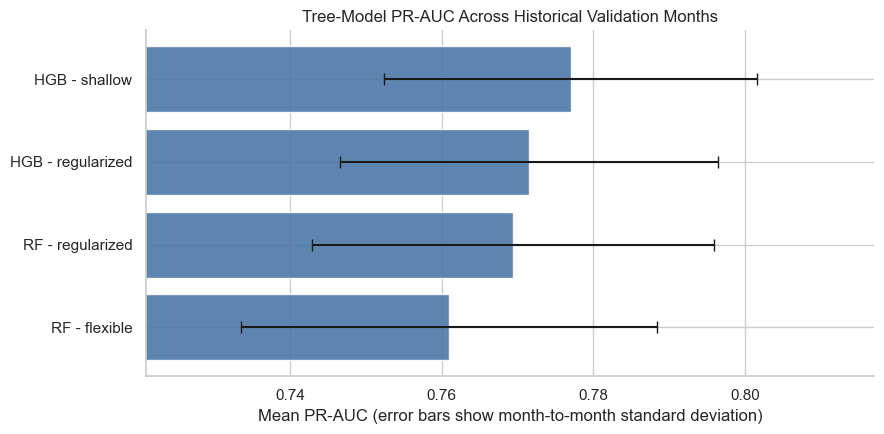

In [5]:
plot_data = tree_summary.sort_values('MeanPRAUC')
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(plot_data['Candidate'], plot_data['MeanPRAUC'], xerr=plot_data['StdPRAUC'],
        color='#4C78A8', alpha=0.9, capsize=4)
ax.set_xlim(max(0, plot_data['MeanPRAUC'].min() - 0.04),
            plot_data['MeanPRAUC'].max() + 0.04)
ax.set(title='Tree-Model PR-AUC Across Historical Validation Months',
       xlabel='Mean PR-AUC (error bars show month-to-month standard deviation)', ylabel='')
sns.despine()
plt.tight_layout()
plt.show()

## 4. Compare the best tree with logistic regression before opening the test

The champion should be chosen mainly from repeated historical validation—not from whichever model barely wins one final month. We therefore reproduce logistic selection on exactly the same folds.

In [6]:
selected_c, logistic_summary, logistic_validation_predictions = rolling_logistic_validation(
    churn_data, folds, c_values=[0.001, 0.01, 0.1, 1.0, 10.0],
    contract=feature_contract,
)
best_logistic_validation = logistic_summary.iloc[0]
best_tree_validation = tree_summary.iloc[0]
validation_comparison = pd.DataFrame({
    'Logistic regression': best_logistic_validation,
    selected_tree: best_tree_validation,
}).T[['MeanPRAUC', 'StdPRAUC', 'MeanROCAUC', 'MeanLiftAt20Pct',
      'MeanBrierScore', 'MeanBalancedAccuracy', 'MeanF1']]
display(validation_comparison.round(4))

,MeanPRAUC,StdPRAUC,MeanROCAUC,MeanLiftAt20Pct,MeanBrierScore,MeanBalancedAccuracy,MeanF1
Logistic regression,0.787999,0.019309,0.77583,1.489583,0.20761,0.696256,0.691467
HGB - shallow,0.777001,0.024563,0.766562,1.454382,0.223092,0.668558,0.622503


## 5. Choose each model's operating threshold using validation only

A threshold converts probability into a high-risk decision. Balanced accuracy is the primary threshold criterion and F1 breaks ties. This is separate from selecting the underlying ranking model. In production, the threshold may instead be set by campaign capacity or expected financial value.

In [7]:
threshold_grid = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50,
                  0.55, 0.60, 0.65, 0.70, 0.75]
tree_threshold, tree_threshold_summary = tune_tree_probability_threshold(
    tree_validation_predictions, selected_tree, threshold_grid
)
logistic_threshold, logistic_threshold_summary = tune_probability_threshold(
    logistic_validation_predictions, selected_c, threshold_grid
)
print(f'Logistic threshold: {logistic_threshold:.2f}')
print(f'Tree threshold:     {tree_threshold:.2f}')

Logistic threshold: 0.40
Tree threshold:     0.35


## 6. Freeze both models and open September once

The selected settings are now fixed. Both models train on the same safely labelled development rows; July and August are purged because their 90-day outcomes overlap the September scoring date.

In [8]:
development_idx, test_idx, purged_idx = final_temporal_holdout(
    churn_data, pd.Timestamp('2011-09-01'), horizon_days=90
)
X_development = churn_data.loc[development_idx, feature_contract.all_features]
y_development = churn_data.loc[development_idx, 'Churn']
X_test = churn_data.loc[test_idx, feature_contract.all_features]
y_test = churn_data.loc[test_idx, 'Churn']

logistic_model = build_logistic_pipeline(feature_contract, regularization_c=selected_c)
tree_family, tree_parameters = tree_candidates[selected_tree]
tree_model = build_tree_pipeline(feature_contract, tree_family, tree_parameters)
logistic_model.fit(X_development, y_development)
tree_model.fit(X_development, y_development)

def evaluate_model(model, threshold):
    probability = model.predict_proba(X_test)[:, 1]
    prediction = (probability >= threshold).astype('int8')
    return probability, prediction, {
        **baseline_metrics(y_test, prediction, probability),
        'BrierScore': brier_score_loss(y_test, probability),
        'PredictedHighRiskShare': prediction.mean(),
    }

logistic_probability, logistic_prediction, logistic_metrics = evaluate_model(
    logistic_model, logistic_threshold
)
tree_probability, tree_prediction, tree_metrics = evaluate_model(
    tree_model, tree_threshold
)
test_comparison = pd.DataFrame({
    'Logistic regression': logistic_metrics,
    selected_tree: tree_metrics,
}).T
display(test_comparison.round(4))

,Precision,Recall,F1,BalancedAccuracy,ROCAUC,PRAUC,LiftAt20Pct,BrierScore,PredictedHighRiskShare
Logistic regression,0.6119,0.5882,0.5998,0.6731,0.7591,0.6473,1.8035,0.1979,0.3782
HGB - shallow,0.5532,0.7932,0.6518,0.6889,0.7636,0.6549,1.7713,0.1923,0.5640


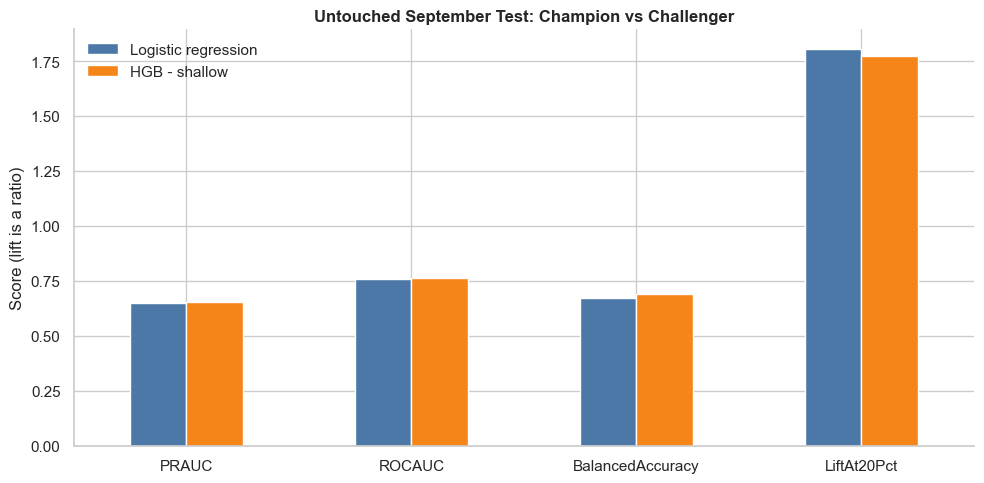

In [9]:
metrics = ['PRAUC', 'ROCAUC', 'BalancedAccuracy', 'LiftAt20Pct']
test_comparison[metrics].T.plot(
    kind='bar', figsize=(10, 5), rot=0, color=['#4C78A8', '#F58518']
)
plt.title('Untouched September Test: Champion vs Challenger', weight='bold')
plt.xlabel('')
plt.ylabel('Score (lift is a ratio)')
plt.legend(title='', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

## 7. Understand what the tree uses

Permutation importance measures how much test PR-AUC falls when one raw feature is randomly shuffled. A larger decrease means that feature was more useful to this fitted model. This describes predictive reliance, not causation; correlated features can substitute for one another and therefore appear less important individually.

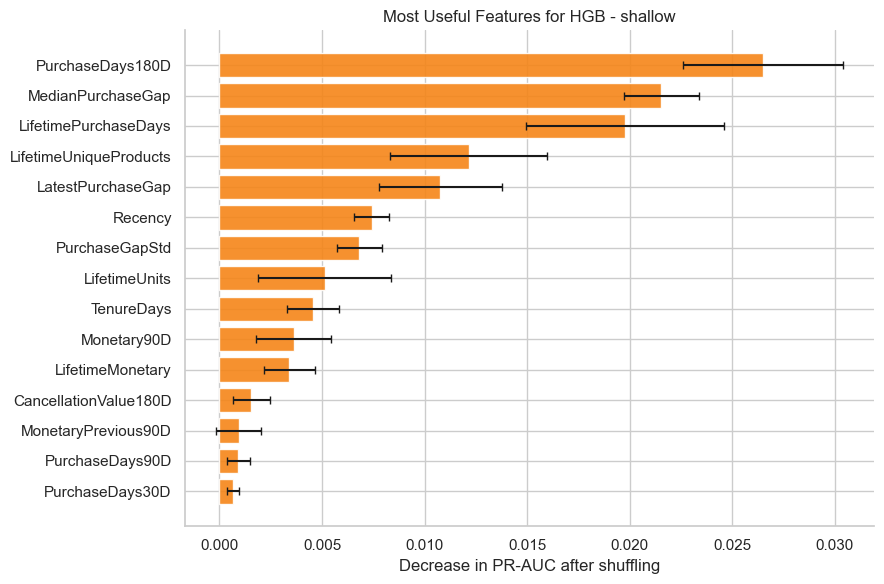

,Feature,Mean PR-AUC decrease,Std
20,PurchaseDays180D,0.0265,0.0039
31,MedianPurchaseGap,0.0215,0.0018
2,LifetimePurchaseDays,0.0198,0.0048
6,LifetimeUniqueProducts,0.0121,0.0038
32,LatestPurchaseGap,0.0108,0.0030
0,Recency,0.0074,0.0009
33,PurchaseGapStd,0.0068,0.0011
5,LifetimeUnits,0.0051,0.0032
1,TenureDays,0.0045,0.0013
18,Monetary90D,0.0036,0.0018


In [10]:
importance = permutation_importance(
    tree_model, X_test, y_test, scoring='average_precision',
    n_repeats=5, random_state=42, n_jobs=-1,
)
importance_df = pd.DataFrame({
    'Feature': feature_contract.all_features,
    'Mean PR-AUC decrease': importance.importances_mean,
    'Std': importance.importances_std,
}).sort_values('Mean PR-AUC decrease', ascending=False).head(15)
plot_importance = importance_df.sort_values('Mean PR-AUC decrease')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_importance['Feature'], plot_importance['Mean PR-AUC decrease'],
        xerr=plot_importance['Std'], color='#F58518', alpha=0.9, capsize=3)
ax.set(title=f'Most Useful Features for {selected_tree}',
       xlabel='Decrease in PR-AUC after shuffling', ylabel='')
sns.despine()
plt.tight_layout()
plt.show()
display(importance_df.round(4))

## Model decision

**Keep logistic regression as the current champion; retain shallow gradient boosting as the challenger.**

The tree's September PR-AUC is slightly higher (about **0.655 vs 0.647**) and its threshold-based F1 is higher because it flags many more customers. However, logistic regression has better repeated validation PR-AUC (**0.788 vs 0.777**), slightly better top-20% test lift (**1.80× vs 1.77×**), flags about **38% rather than 56%** of customers, and is easier to explain and govern. A one-month PR-AUC gain of roughly 0.008 is not enough evidence to accept the extra complexity.

This is a champion–challenger decision, not a claim that the tree is poor. If future out-of-time cohorts repeatedly show a material tree advantage—or the business prioritizes recall and can contact more than half the customer base—the decision should be revisited. Next, translate the champion's probabilities into campaign-priority bands and capacity scenarios.